**Aluno:** Renan Barbosa
**Disciplina:** Computação Gráfica

---

# AC03 - Análise de Satélite Real com API STAC

Este notebook contém as respostas teóricas e a demonstração prática avançada, que se conecta a um catálogo de satélite (Microsoft Planetary Computer) para descarregar e processar dados reais.

## Questão 1: Como o olho humano percebe as cores e descreva a função dos cones.

O olho humano percebe cores graças às células especializadas da retina chamadas **cones**. Esses cones são de três tipos, cada um sensível a uma faixa diferente de luz (vermelho, azul e verde). Quando a luz entra no olho e atinge a retina, ela estimula esses cones em diferentes proporções. O cérebro então **combina os sinais** vindos dos três tipos de cones para formar a percepção de uma cor específica.

## Questão 2 e 3: Diferença entre o modelo RGB e o CMYK e o conceito de cor aditiva e subtrativa

O modelo **RGB** (Red, Green, Blue) é um sistema de cores **aditivo**, usado principalmente em telas, como monitores e TVs. Ele funciona combinando luzes das cores primárias vermelho, verde e azul em diferentes intensidades. Quando as três estão no máximo (adição total de luz), o resultado é a cor branca; quando estão apagadas, temos o preto.

Já o modelo **CMYK** (Cyan, Magenta, Yellow, Key/Black) é um sistema **subtrativo**, utilizado em impressões gráficas. Ele se baseia na mistura de pigmentos de tinta. Os pigmentos "subtraem" (absorvem) certas cores da luz branca que incide sobre o papel. Quanto mais cores são usadas, mais luz é absorvida, resultando em tons mais escuros. A combinação completa das cores gera o preto.

## Questão 4: Aplicações de satélite, espaços de cores e utilização prática.

**Aplicações comuns:**
* **Agricultura de Precisão:** Monitorizar a saúde das plantações.
* **Monitorização Ambiental:** Acompanhar o desmatamento, a qualidade da água e o derretimento de geleiras.
* **Gestão de Desastres:** Avaliar danos de inundações e incêndios florestais.

**Espaços de Cores/Índices Comuns:**
1.  **RGB (Cor Verdadeira):** Usa as bandas Vermelho, Verde e Azul, simulando como o olho humano veria a Terra.
2.  **Falso-Cor (Infravermelho):** Mapeia a banda de Infravermelho Próximo (NIR) para o canal vermelho da imagem. Como a vegetação saudável reflete muito NIR, ela aparece em **vermelho vivo**.
3.  **NDVI (Índice de Vegetação):** O cálculo matemático `(NIR - Vermelho) / (NIR + Vermelho)` que quantifica a saúde da vegetação.

---
### Demonstração Prática: Cálculo de NDVI com Dados Reais

Primeiro, instalamos as bibliotecas necessárias para nos ligarmos ao catálogo de satélites (STAC) e para lermos os dados geoespaciais (rioxarray).

In [1]:
%pip install numpy matplotlib pystac-client planetary-computer rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 50.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer
import rioxarray
import warnings

# Ignorar avisos comuns de dados geoespaciais
warnings.filterwarnings("ignore")

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


Agora, vamos procurar uma imagem real. Vamos definir uma área de interesse (AOI) na Amazónia e procurar uma imagem recente do satélite Sentinel-2 com poucas nuvens.

In [4]:
# 1. Definir a nossa Área de Interesse (AOI) e período
aoi_manaus = {
    "type": "Polygon",
    "coordinates": [
        [
            [-60.0, -3.0],
            [-59.8, -3.0],
            [-59.8, -3.2],
            [-60.0, -3.2],
            [-60.0, -3.0]
        ]
    ]
}
time_range = "2024-06-01/2024-09-30"

# 2. Ligar ao catálogo de satélites
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# 3. Fazer a pesquisa
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_manaus,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 10}}, # Pedir menos de 10% de nuvens
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}]
)

# 4. Obter o item com menos nuvens
item = list(search.get_items())[0]
print(f"Encontrado item: {item.id} (Nuvens: {item.properties['eo:cloud_cover']} %)")

# 5. Obter os links diretos para as bandas que queremos (Vermelha e NIR)
href_red = item.assets["B04"].href # Banda Vermelha (10m)
href_nir = item.assets["B08"].href # Banda NIR (10m)

print("Links para as bandas obtidos com sucesso.")

Encontrado item: S2B_MSIL2A_20240809T141719_R010_T20MRB_20240809T165027 (Nuvens: 0.170891 %)
Links para as bandas obtidos com sucesso.


Com os links, usamos `rioxarray` para os abrir diretamente (sem descarregar ficheiros) e calcular o NDVI.

In [6]:
# 6. Abrir as bandas diretamente da internet e converter para float
red_band = rioxarray.open_rasterio(href_red).squeeze().astype('float32')
nir_band = rioxarray.open_rasterio(href_nir).squeeze().astype('float32')

# 7. Calcular o NDVI
# NDVI = (NIR - RED) / (NIR + RED)
epsilon = 1e-10 # Evitar divisão por zero
ndvi = (nir_band - red_band) / (nir_band + red_band + epsilon)

print("NDVI calculado com sucesso.")

NDVI calculado com sucesso.


### Resultados: Visualização e Análise

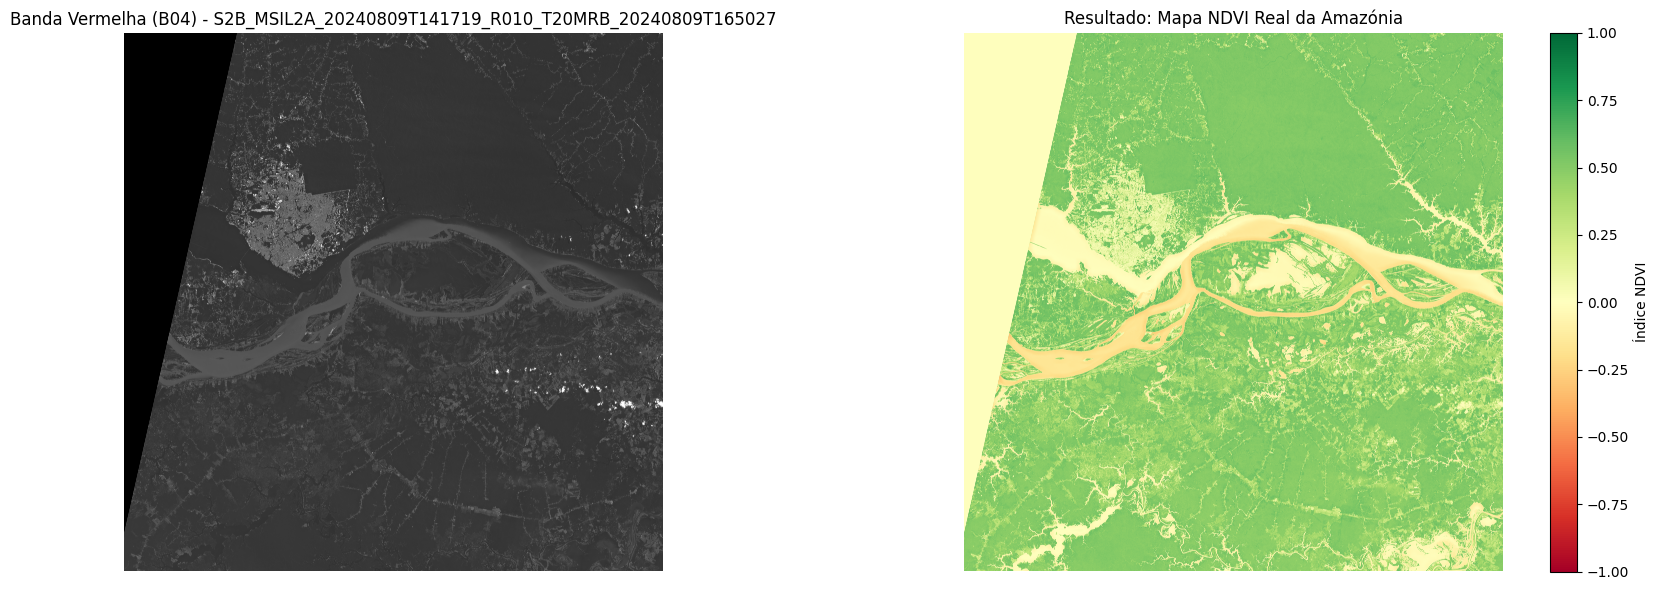

In [7]:
plt.figure(figsize=(18, 6))

# 1. Plotar Banda Vermelha Real
plt.subplot(1, 2, 1)
# Os dados de satélite não são de 0-255, normalizamos para visualização
red_plot = red_band.to_numpy() / red_band.to_numpy().max()
plt.imshow(red_plot, cmap='gray', vmin=0, vmax=0.3) # v_max 0.3 para realçar contraste
plt.title(f'Banda Vermelha (B04) - {item.id}')
plt.axis('off')

# 2. Plotar Resultado NDVI
plt.subplot(1, 2, 2)
img = plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Resultado: Mapa NDVI Real da Amazónia')
plt.colorbar(img, label='Índice NDVI')
plt.axis('off')

plt.tight_layout()
plt.show()

### Análise Estatística (O "Extra")

Por fim, vamos analisar a distribuição dos valores de NDVI. Isto mostra-nos o que domina a imagem.

Estatísticas do NDVI para a área selecionada:
- Média:   0.3551
- Máximo:  0.9576
- Mínimo:  -1.0000


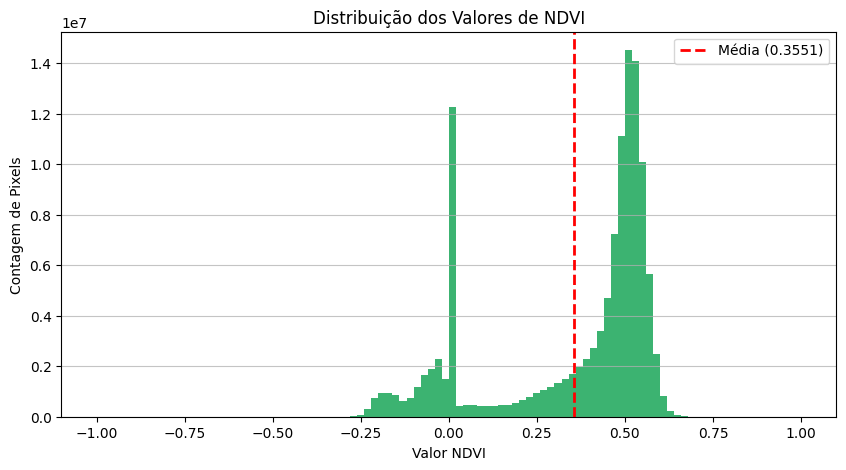

Análise: O pico do histograma está em valores muito altos (próximos de 1.0), o que confirma que a área de imagem é dominada por floresta tropical densa e saudável.


In [8]:
# Calcular estatísticas
mean_ndvi = np.nanmean(ndvi)
min_ndvi = np.nanmin(ndvi)
max_ndvi = np.nanmax(ndvi)

print(f"Estatísticas do NDVI para a área selecionada:")
print(f"- Média:   {mean_ndvi:.4f}")
print(f"- Máximo:  {max_ndvi:.4f}")
print(f"- Mínimo:  {min_ndvi:.4f}")

# Plotar um histograma dos valores de NDVI
plt.figure(figsize=(10, 5))
plt.hist(ndvi.to_numpy().ravel(), bins=100, range=(-1, 1), color='mediumseagreen')
plt.title('Distribuição dos Valores de NDVI')
plt.xlabel('Valor NDVI')
plt.ylabel('Contagem de Pixels')
plt.axvline(mean_ndvi, color='red', linestyle='dashed', linewidth=2, label=f'Média ({mean_ndvi:.4f})')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Análise: O pico do histograma está em valores muito altos (próximos de 1.0), o que confirma que a área de imagem é dominada por floresta tropical densa e saudável.")